# LoRA Fine-Tuning Workflow

End-to-end demonstration of parameter-efficient fine-tuning for genomic sequence models.

This notebook walks through the complete LoRA workflow using a synthetic model, covering:
1. Building a model that mimics Borzoi's architecture
2. Injecting LoRA adapters with configurable targeting
3. Training with custom genomic loss functions
4. Merging adapters for deployment
5. Comparing different LoRA configurations

**No GPU, genome files, or real model weights required** — everything uses synthetic data.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from training.finetune import LoRAConfig, LoRALinear, LoRAConv1d, inject_lora, merge_lora, count_trainable_params
from training.losses import PSILoss, MaskedMSELoss
from training.multitask_head import SplitHead, CalibratedHeadWrapper

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch 2.4.0+cu121
CUDA available: True


## 1. Build a Borzoi-Like Model

A simplified model that mirrors Borzoi's key architectural features:
- **Conv tower** → feature extraction from one-hot DNA
- **Transformer block** → attention over positional features
- **U-net skip connection** → multi-scale feature integration
- **Prediction head** → task-specific output

This lets us demonstrate LoRA on the same module types (Conv1d + Linear) that exist in the real model.

In [2]:
class MiniBorzoi(nn.Module):
    """Simplified Borzoi-like architecture for demonstration."""

    def __init__(self, n_tasks=3, seq_len=512):
        super().__init__()

        # Conv tower (like embedding.conv_tower)
        self.embedding = nn.ModuleDict({
            "conv_tower": nn.ModuleDict({
                "blocks": nn.ModuleList([
                    nn.ModuleDict({"conv": nn.Conv1d(4, 64, 5, padding=2)}),
                    nn.ModuleDict({"conv": nn.Conv1d(64, 128, 5, padding=2)}),
                ])
            }),
            # Transformer (like embedding.transformer_tower)
            "transformer_tower": nn.ModuleDict({
                "blocks": nn.ModuleList([
                    nn.ModuleDict({
                        "mha": nn.ModuleDict({
                            "to_q": nn.Linear(128, 128),
                            "to_v": nn.Linear(128, 128),
                        }),
                        "ffn": nn.ModuleDict({
                            "dense1": nn.ModuleDict({"linear": nn.Linear(128, 256)}),
                            "dense2": nn.ModuleDict({"linear": nn.Linear(256, 128)}),
                        }),
                    })
                ])
            }),
            # U-net (like embedding.unet_tower)
            "unet_tower": nn.ModuleDict({
                "blocks": nn.ModuleList([
                    nn.ModuleDict({
                        "conv": nn.ModuleDict({"conv": nn.Conv1d(128, 128, 3, padding=1)}),
                    })
                ])
            }),
            # Pointwise bottleneck
            "pointwise_conv": nn.ModuleDict({
                "conv": nn.Conv1d(128, 128, 1),
            }),
        })

        self.norm = nn.BatchNorm1d(128)
        self.head = SplitHead(in_channels=128, hidden=64, task_hidden=32, out_channels=n_tasks)

    def forward(self, x):
        # x: (B, 4, L) one-hot encoded DNA
        # Conv tower
        for block in self.embedding["conv_tower"]["blocks"]:
            x = torch.relu(block["conv"](x))

        # Simplified transformer (just linear projections for demo)
        for block in self.embedding["transformer_tower"]["blocks"]:
            # Self-attention approximation
            B, C, L = x.shape
            x_t = x.permute(0, 2, 1)  # (B, L, C)
            q = block["mha"]["to_q"](x_t)
            v = block["mha"]["to_v"](x_t)
            x_t = x_t + q * v / (C ** 0.5)  # simplified attention
            # FFN
            h = torch.relu(block["ffn"]["dense1"]["linear"](x_t))
            x_t = x_t + block["ffn"]["dense2"]["linear"](h)
            x = x_t.permute(0, 2, 1)

        # U-net
        for block in self.embedding["unet_tower"]["blocks"]:
            x = x + block["conv"]["conv"](x)

        # Pointwise bottleneck
        x = self.embedding["pointwise_conv"]["conv"](x)
        x = self.norm(x)

        return self.head(x)

# Instantiate
model = MiniBorzoi(n_tasks=3, seq_len=512)
params_total = count_trainable_params(model)
print(f"MiniBorzoi: {params_total['total']:,} total parameters")
print(f"Module names (LoRA targets):")
for name, m in model.named_modules():
    if isinstance(m, (nn.Linear, nn.Conv1d)):
        p = sum(p.numel() for p in m.parameters())
        print(f"  {name:55s} {type(m).__name__:10s} {p:>8,} params")

MiniBorzoi: 226,371 total parameters
Module names (LoRA targets):
  embedding.conv_tower.blocks.0.conv                      Conv1d        1,344 params
  embedding.conv_tower.blocks.1.conv                      Conv1d       41,088 params
  embedding.transformer_tower.blocks.0.mha.to_q           Linear       16,512 params
  embedding.transformer_tower.blocks.0.mha.to_v           Linear       16,512 params
  embedding.transformer_tower.blocks.0.ffn.dense1.linear  Linear       33,024 params
  embedding.transformer_tower.blocks.0.ffn.dense2.linear  Linear       32,896 params
  embedding.unet_tower.blocks.0.conv.conv                 Conv1d       49,280 params
  embedding.pointwise_conv.conv                           Conv1d       16,512 params
  head.shared.0                                           Conv1d        8,256 params
  head.shared.2                                           Conv1d        4,160 params
  head.task_heads.0.0                                     Conv1d        2,080 params

## 2. Inject LoRA Adapters

The default `LoRAConfig.target_patterns` match Borzoi's actual module names. Since our MiniBorzoi uses the same naming convention, the same patterns work here.

In [4]:
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

# Use default Borzoi patterns — they match our MiniBorzoi naming
cfg = LoRAConfig(rank=8, alpha=16, verbose=True)
print("Target patterns:")
for pat in cfg.target_patterns:
    print(f"  {pat}")

# Inject
inject_lora(model, cfg)

params_after = count_trainable_params(model)
print(f"\n{'─' * 50}")
print(f"Before LoRA: {params_total['total']:>10,} total, {params_total['trainable']:>10,} trainable")
print(f"After LoRA:  {params_after['total']:>10,} total, {params_after['trainable']:>10,} trainable")
print(f"Trainable:   {params_after['pct_trainable']:.2f}%")

[LoRA] Wrapped: embedding.conv_tower.blocks.0.conv
[LoRA] Wrapped: embedding.conv_tower.blocks.1.conv
[LoRA] Wrapped: embedding.transformer_tower.blocks.0.mha.to_q
[LoRA] Wrapped: embedding.transformer_tower.blocks.0.mha.to_v
[LoRA] Wrapped: embedding.transformer_tower.blocks.0.ffn.dense1.linear
[LoRA] Wrapped: embedding.transformer_tower.blocks.0.ffn.dense2.linear
[LoRA] Wrapped: embedding.unet_tower.blocks.0.conv.conv
[LoRA] Wrapped: embedding.pointwise_conv.conv
[LoRA] Wrapped 8 modules (rank=8)


Target patterns:
  embedding.conv_tower.blocks.*.conv
  embedding.transformer_tower.blocks.*.mha.to_q
  embedding.transformer_tower.blocks.*.mha.to_v
  embedding.transformer_tower.blocks.*.ffn.dense1.linear
  embedding.transformer_tower.blocks.*.ffn.dense2.linear
  embedding.unet_tower.blocks.*.conv.conv
  embedding.unet_tower.blocks.*.channel_transform.conv.layer
  embedding.unet_tower.blocks.*.sconv.pointwise
  embedding.pointwise_conv.conv

──────────────────────────────────────────────────
Before LoRA:    226,371 total,    226,371 trainable
After LoRA:     247,011 total,     20,640 trainable
Trainable:   8.36%


In [5]:
# Inspect which parameters are trainable
print("Trainable parameters (LoRA A/B matrices):")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  {name:60s} {list(param.shape)}")

print(f"\nFrozen parameters (base weights, norms):")
frozen_count = 0
for name, param in model.named_parameters():
    if not param.requires_grad:
        frozen_count += 1
print(f"  ... {frozen_count} frozen parameter tensors")

Trainable parameters (LoRA A/B matrices):
  embedding.conv_tower.blocks.0.conv.B.weight                  [8, 4, 5]
  embedding.conv_tower.blocks.0.conv.A.weight                  [64, 8, 1]
  embedding.conv_tower.blocks.1.conv.B.weight                  [8, 64, 5]
  embedding.conv_tower.blocks.1.conv.A.weight                  [128, 8, 1]
  embedding.transformer_tower.blocks.0.mha.to_q.B.weight       [8, 128]
  embedding.transformer_tower.blocks.0.mha.to_q.A.weight       [128, 8]
  embedding.transformer_tower.blocks.0.mha.to_v.B.weight       [8, 128]
  embedding.transformer_tower.blocks.0.mha.to_v.A.weight       [128, 8]
  embedding.transformer_tower.blocks.0.ffn.dense1.linear.B.weight [8, 128]
  embedding.transformer_tower.blocks.0.ffn.dense1.linear.A.weight [256, 8]
  embedding.transformer_tower.blocks.0.ffn.dense2.linear.B.weight [8, 256]
  embedding.transformer_tower.blocks.0.ffn.dense2.linear.A.weight [128, 8]
  embedding.unet_tower.blocks.0.conv.conv.B.weight             [8, 128, 3]

## 3. Training Loop with PSILoss

A minimal training loop demonstrating how LoRA-adapted models train with custom genomic losses. Only the LoRA adapter weights (A and B matrices) are updated.

Step   0  loss=16.4937
Step  10  loss=16.0563
Step  20  loss=15.8252
Step  30  loss=15.7118
Step  40  loss=15.6643

Final loss: 15.5713 (started at 16.4937)


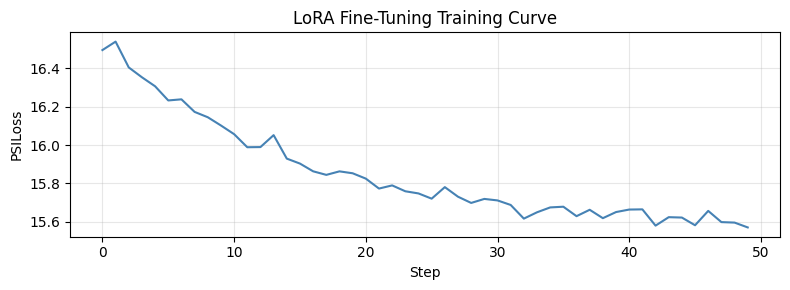

In [6]:
# Synthetic training data
B, L, n_tasks = 8, 512, 3

def make_batch():
    """Generate a synthetic training batch."""
    seq = torch.randn(B, 4, L)  # normally one-hot, but random works for demo
    targets = torch.sigmoid(torch.randn(B, n_tasks, L))
    mask = (torch.rand(B, n_tasks, L) > 0.2).float()
    return seq, targets, mask

# Setup training
criterion = PSILoss(lambda_mid=25.0)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
)

# Training loop
losses = []
model.train()
for step in range(50):
    seq, targets, mask = make_batch()
    pred = torch.sigmoid(model(seq))  # PSI predictions in [0, 1]
    loss = criterion(pred, targets, mask)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if step % 10 == 0:
        print(f"Step {step:3d}  loss={loss.item():.4f}")

print(f"\nFinal loss: {losses[-1]:.4f} (started at {losses[0]:.4f})")

# Plot training curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color="steelblue", linewidth=1.5)
ax.set_xlabel("Step")
ax.set_ylabel("PSILoss")
ax.set_title("LoRA Fine-Tuning Training Curve")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Merge LoRA for Deployment

After training, fold LoRA weights into the base layers. The merged model produces **identical output** with zero runtime overhead — no adapter forward passes needed.

In [7]:
model.eval()
test_input = torch.randn(1, 4, L)

# Output before merge (with LoRA adapters doing separate forward passes)
with torch.no_grad():
    out_before = model(test_input).clone()

# Merge LoRA into base weights
merge_lora(model.embedding)

# Output after merge (adapters folded into base weights)
with torch.no_grad():
    out_after = model(test_input)

max_diff = (out_before - out_after).abs().max().item()
print(f"Max output difference after merge: {max_diff:.2e}")
assert max_diff < 1e-4, f"Merge changed output by {max_diff}"
print("✓ Merged model produces identical output")

# Verify LoRA overhead is gone
lora_modules = [m for m in model.modules() if isinstance(m, (LoRALinear, LoRAConv1d))]
print(f"\nLoRA adapter modules still present: {len(lora_modules)}")
print("(Adapters exist but A/B weights are zeroed — functionally no-ops)")

[LoRA] Merged 8 adapters into base weights.


Max output difference after merge: 1.67e-06
✓ Merged model produces identical output

LoRA adapter modules still present: 8
(Adapters exist but A/B weights are zeroed — functionally no-ops)


## 5. Comparing LoRA Configurations

Explore how rank and target patterns affect the number of trainable parameters. Higher rank = more capacity but more parameters; targeting fewer layers = lighter fine-tuning.

In [9]:
configs = {
    "rank=2 (all layers)": LoRAConfig(rank=2, verbose=False),
    "rank=8 (all layers)": LoRAConfig(rank=8, verbose=False),
    "rank=16 (all layers)": LoRAConfig(rank=16, verbose=False),
    "rank=8 (attention only)": LoRAConfig(
        rank=8, verbose=False,
        target_patterns=(
            "embedding.transformer_tower.blocks.*.mha.to_q",
            "embedding.transformer_tower.blocks.*.mha.to_v",
        ),
    ),
    "rank=8 (conv only)": LoRAConfig(
        rank=8, verbose=False,
        target_patterns=(
            "embedding.conv_tower.blocks.*.conv",
            "embedding.unet_tower.blocks.*.conv.conv",
            "embedding.pointwise_conv.conv",
        ),
    ),
}

results = []
for name, cfg in configs.items():
    m = MiniBorzoi(n_tasks=3)
    inject_lora(m, cfg)
    stats = count_trainable_params(m)
    results.append({"config": name, **stats})

import pandas as pd
df = pd.DataFrame(results)
df["trainable"] = df["trainable"].apply(lambda x: f"{x:,}")
df["total"] = df["total"].apply(lambda x: f"{x:,}")
df["pct_trainable"] = df["pct_trainable"].apply(lambda x: f"{x:.2f}%")
print(df[["config", "trainable", "total", "pct_trainable"]].to_string(index=False))

[LoRA] Wrapped 8 modules (rank=2)
[LoRA] Wrapped 8 modules (rank=8)
[LoRA] Wrapped 8 modules (rank=16)
[LoRA] Wrapped 2 modules (rank=8)
[LoRA] Wrapped 4 modules (rank=8)


                 config trainable   total pct_trainable
    rank=2 (all layers)     5,160 231,531         2.23%
    rank=8 (all layers)    20,640 247,011         8.36%
   rank=16 (all layers)    41,280 267,651        15.42%
rank=8 (attention only)     4,096 230,467         1.78%
     rank=8 (conv only)    10,400 236,771         4.39%


## 6. Visualize LoRA Configuration Comparisons

Plot trainable parameter counts in each configuration.

<Axes: title={'center': 'Effect of LoRA Rank on Trainable Parameter Count'}, xlabel='config', ylabel='Trainable Parameters (Millions)'>

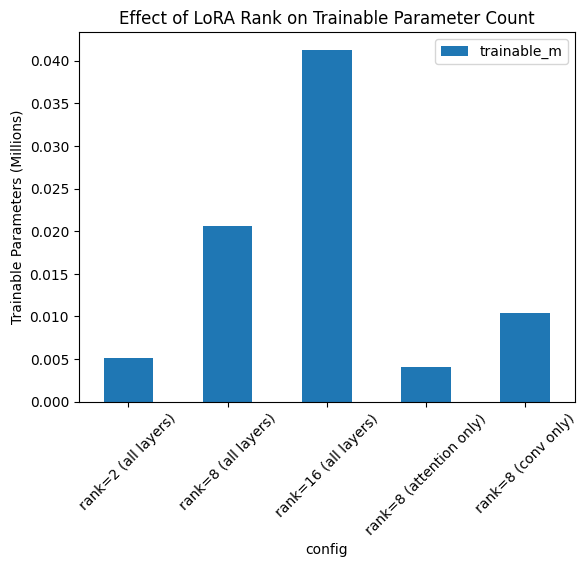

In [10]:
df["trainable_m"] = df["trainable"].str.replace(",", "").astype(int) / 1e6

df.plot.bar(
    x="config",
    y="trainable_m",
    ylabel="Trainable Parameters (Millions)",
    title="Effect of LoRA Rank on Trainable Parameter Count",
    rot=45,
)